# Plotting Template Script

This notebook defines the standard color palettes, plot formats, and styling used across all analysis notebooks for the FOMOsim project.

**Author:** Sjovik & Sund  
**Date:** February 2026

---

## Overview

This template provides:
- **Color Palettes**: Consistent color schemes for different plot types
- **Plot Templates**: Reusable plotting functions for common visualizations
- **Styling Standards**: Font sizes, figure sizes, and formatting
- **Helper Functions**: Utilities for data processing and formatting

For more plots see: from_project -> plots -> specialization_project_plots.ipynb

## 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path

## 2. Color Palettes

In [2]:
# Primary Color Palette
PRIMARY_COLORS = [
    ("Warm Red", "#D1495B"),
    ("Dark Spruce", "#344E41"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Sunset Orange", "#EC703F"),
]

# Grayscale Palette (for criticality plots)
GRAYSCALE_COLORS = [
    ("Dark Grey", "#616161"),
    ("Medium Grey", "#929292"),
    ("Light Grey", "#C2C2C2"),
    ("Mist Grey", "#E6E6E6"),
]

# Activity-specific colors
ACTIVITY_COLORS = {
    "Demand": PRIMARY_COLORS[1][1],          # Dark Spruce
    "Rebalance": PRIMARY_COLORS[6][1],       # Sage Green
    "Maintenance": PRIMARY_COLORS[3][1],     # Blue Accent
    "Criticality": PRIMARY_COLORS[0][1],     # Warm Red
    "Maint_starvations": PRIMARY_COLORS[0][1],  # Warm Red
    "Bike_starvations": PRIMARY_COLORS[7][1],   # Sunset Orange
    "Congestions": PRIMARY_COLORS[2][1]      # Ochre Gold
}

# Display color palette
print("Primary Colors:")
for name, hex_code in PRIMARY_COLORS:
    print(f"  {name:20s} {hex_code}")

print("\nActivity Colors:")
for activity, hex_code in ACTIVITY_COLORS.items():
    print(f"  {activity:20s} {hex_code}")

Primary Colors:
  Warm Red             #D1495B
  Dark Spruce          #344E41
  Ochre Gold           #EDAE49
  Blue Accent          #526ECA
  Mist Grey            #E6E6E6
  Pale Fern            #D9E5D6
  Sage Green           #84A579
  Sunset Orange        #EC703F

Activity Colors:
  Demand               #344E41
  Rebalance            #84A579
  Maintenance          #526ECA
  Criticality          #D1495B
  Maint_starvations    #D1495B
  Bike_starvations     #EC703F
  Congestions          #EDAE49


In [3]:
def get_color(index, palette="primary"):
    """
    Get color hex code by index.
    
    Args:
        index (int): Index of color in palette
        palette (str): 'primary' or 'grayscale'
    
    Returns:
        str: Hex color code
    """
    if palette == "grayscale":
        return GRAYSCALE_COLORS[index % len(GRAYSCALE_COLORS)][1]
    else:
        return PRIMARY_COLORS[index % len(PRIMARY_COLORS)][1]

## 3. Global Plot Settings

In [4]:
# Font sizes
FONT_SIZE_TITLE = 16
FONT_SIZE_LABEL = 14
FONT_SIZE_TICK = 12
FONT_SIZE_LEGEND = 12
FONT_SIZE_ANNOTATION = 11

# Figure sizes (width, height in inches)
FIGSIZE_SMALL = (10, 6)
FIGSIZE_MEDIUM = (16, 6)
FIGSIZE_LARGE = (20, 6)
FIGSIZE_SQUARE = (8, 8)

# Plot styling parameters
ALPHA_DEFAULT = 1.0
LINEWIDTH_DEFAULT = 2
LINEWIDTH_THIN = 1
GRID_ALPHA = 0.3

## 4. Helper Functions

In [5]:
def setup_plot_style():
    """
    Set up the default matplotlib style for all plots.
    Call this at the beginning of your script.
    """
    plt.rcParams['font.size'] = FONT_SIZE_TICK
    plt.rcParams['axes.labelsize'] = FONT_SIZE_LABEL
    plt.rcParams['axes.titlesize'] = FONT_SIZE_TITLE
    plt.rcParams['xtick.labelsize'] = FONT_SIZE_TICK
    plt.rcParams['ytick.labelsize'] = FONT_SIZE_TICK
    plt.rcParams['legend.fontsize'] = FONT_SIZE_LEGEND
    plt.rcParams['figure.titlesize'] = FONT_SIZE_TITLE
    print("✓ Plot style configured")

In [6]:
def save_plot(filename, tight=True, pad=0.02):
    """
    Save plot with consistent settings.
    
    Args:
        filename (str): Output filename (include extension, e.g., .svg, .png)
        tight (bool): Use tight_layout before saving
        pad (float): Padding in inches
    """
    if tight:
        plt.tight_layout()
    
    plt.savefig(
        filename,
        bbox_inches='tight',
        pad_inches=pad,
        dpi=300  # High resolution for PNG
    )
    print(f"✓ Saved: {filename}")

In [7]:
def format_hour_label(hour):
    """Format hour as HH:00 string."""
    return f"{int(hour):02d}:00"

In [8]:
def process_time_data(df, window=3):
    """
    Process hourly data with moving average.
    
    Args:
        df (pd.DataFrame): DataFrame with 'Day' and 'Hour' columns
        window (int): Window size for moving average
        
    Returns:
        pd.DataFrame: Processed dataframe with moving average
    """
    c = df.copy()
    
    # Fix hour=24 to hour=0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
    
    # Sort by Day and Hour
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)
    
    # Calculate moving average if numeric column exists
    numeric_cols = c.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col not in ["Day", "Hour"]:
            c[f"{col}_MA"] = c[col].rolling(window=window, min_periods=1).mean()
    
    # Add hour label
    c["hour_label"] = c["Hour"].apply(format_hour_label)
    
    return c

## 5. Plot Templates

### 5.1 Hourly Bar Plot

In [9]:
def plot_bar_hourly(hours, values, title="", xlabel="Hour", ylabel="Value",
                    color=None, figsize=FIGSIZE_SMALL, show_values=True,
                    save_as=None):
    """
    Template for hourly bar plots.
    
    Args:
        hours (list): Hour values (0-23)
        values (list): Values to plot
        title (str): Plot title
        xlabel (str): X-axis label
        ylabel (str): Y-axis label
        color (str): Bar color (hex code)
        figsize (tuple): Figure size
        show_values (bool): Show value labels on bars
        save_as (str): Filename to save (optional)
    """
    if color is None:
        color = PRIMARY_COLORS[2][1]  # Default: Ochre Gold
    
    # Create hour labels
    hour_labels = [format_hour_label(h) for h in hours]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot bars
    ax.bar(hour_labels, values, color=color, alpha=ALPHA_DEFAULT, width=0.9)
    
    # Labels
    ax.set_xlabel(xlabel, fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE_LABEL)
    if title:
        ax.set_title(title, fontsize=FONT_SIZE_TITLE)
    
    # Add value labels on bars
    if show_values and values:
        max_val = max(values)
        threshold = 0.10 * max_val
        
        for h, v in zip(hour_labels, values):
            if v > 0.01:  # Only show if value is significant
                ax.text(h, v + threshold * 0.1,
                       f"{int(v)}" if v >= 1 else f"{v:.1f}",
                       ha='center', va='bottom',
                       color='black', fontsize=FONT_SIZE_ANNOTATION)
    
    # Styling
    ax.tick_params(axis='x', rotation=45, labelsize=FONT_SIZE_TICK)
    ax.tick_params(axis='y', labelsize=FONT_SIZE_TICK)
    
    # Save or show
    if save_as:
        save_plot(save_as)
    
    plt.show()

### 5.2 Timeline with Dual Axis

In [10]:
def plot_timeline_dual_axis(x, values, day_labels, day_positions,
                            hour_labels, title="", ylabel="Value",
                            color=None, figsize=FIGSIZE_LARGE,
                            x_step=4, save_as=None):
    """
    Template for timeline plots with dual axis (days on top, hours on bottom).
    
    Args:
        x (array): X-axis positions
        values (array): Values to plot
        day_labels (list): Day labels for top axis
        day_positions (list): Positions for day labels
        hour_labels (list): Hour labels for bottom axis
        title (str): Plot title
        ylabel (str): Y-axis label
        color (str): Bar color
        figsize (tuple): Figure size
        x_step (int): Step size for x-axis ticks
        save_as (str): Filename to save (optional)
    """
    if color is None:
        color = PRIMARY_COLORS[2][1]
    
    # Create figure with bottom axis
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Plot bars
    ax1.bar(x, values, width=0.9, color=color)
    
    # Bottom axis labels
    ax1.set_ylabel(ylabel, fontsize=FONT_SIZE_LABEL)
    ax1.set_xlabel("Hour", fontsize=FONT_SIZE_LABEL)
    
    # Set bottom axis ticks (hours)
    step = min(x_step, len(x)) if len(x) > 0 else 1
    ax1.set_xticks(list(x)[::step])
    ax1.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), step)],
                        rotation=90, fontsize=FONT_SIZE_TICK)
    
    # Create top axis (days)
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(day_positions)
    ax2.set_xticklabels(day_labels, fontsize=FONT_SIZE_TICK, fontweight="bold")
    
    if title:
        plt.title(title, fontsize=FONT_SIZE_TITLE, pad=20)
    
    # Save or show
    if save_as:
        save_plot(save_as)
    
    plt.show()

### 5.3 Line Plot with Moving Average

In [ ]:
def plot_line_with_moving_average(df_list, labels, colors=None,
                                  title="", xlabel="Time", ylabel="Value",
                                  figsize=FIGSIZE_MEDIUM, show_trend=False,
                                  trend_index=0, day_boundaries=None,
                                  save_as=None):
    """
    Template for line plots with multiple series and optional moving average.
    
    Args:
        df_list (list): List of DataFrames, each with 'MA' column for moving average
        labels (list): Labels for each series
        colors (list): Hex colors for each series
        title (str): Plot title
        xlabel (str): X-axis label
        ylabel (str): Y-axis label
        figsize (tuple): Figure size
        show_trend (bool): Show polynomial trend line
        trend_index (int): Index of dataset to use for trend
        day_boundaries (list): Positions of day boundaries for vertical lines
        save_as (str): Filename to save (optional)
    """
    if colors is None:
        colors = [get_color(i) for i in range(len(df_list))]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each series
    for i, (df, label, color) in enumerate(zip(df_list, labels, colors)):
        x = df.index
        y = df['MA'] if 'MA' in df.columns else df.iloc[:, 0]
        
        ax.plot(x, y, label=label, color=color, 
               linewidth=LINEWIDTH_DEFAULT, alpha=ALPHA_DEFAULT)
    
    # Add trend line if requested
    if show_trend and 0 <= trend_index < len(df_list):
        trend_df = df_list[trend_index]
        x_trend = trend_df.index
        y_trend = trend_df['MA'] if 'MA' in trend_df.columns else trend_df.iloc[:, 0]
        
        # Polynomial fit (degree 3)
        coeffs = np.polyfit(x_trend, y_trend, 3)
        poly = np.poly1d(coeffs)
        y_fit = poly(x_trend)
        
        ax.plot(x_trend, y_fit, '--', color='black', 
               linewidth=LINEWIDTH_THIN, alpha=0.7, label='Trend')
    
    # Add day boundary lines
    if day_boundaries:
        for boundary in day_boundaries:
            ax.axvline(x=boundary, color='gray', linestyle='--', 
                      linewidth=LINEWIDTH_THIN, alpha=0.5)
    
    # Set x-axis limits to prevent skewing
    if len(df_list) > 0:
        ax.set_xlim(0, len(df_list[0]) - 1)
        
        # Set x-ticks to show days instead of hours
        n_points = len(df_list[0])
        n_days = int(n_points / 24)  # Assuming 24 hours per day
        
        # Place ticks at the center of each day
        day_ticks = [12 + i * 24 for i in range(n_days)]
        day_labels = [f"Day {i+1}" for i in range(n_days)]
        
        ax.set_xticks(day_ticks)
        ax.set_xticklabels(day_labels, fontsize=FONT_SIZE_TICK)
    
    # Labels and legend
    ax.set_xlabel(xlabel, fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE_LABEL)
    if title:
        ax.set_title(title, fontsize=FONT_SIZE_TITLE)
    
    ax.legend(fontsize=FONT_SIZE_LEGEND, framealpha=0.9)
    ax.tick_params(labelsize=FONT_SIZE_TICK)
    
    # Save or show
    if save_as:
        save_plot(save_as)
    
    plt.show()

### 5.4 Grouped Bar Comparison

In [12]:
def plot_comparison_bars(categories, values_dict, title="", xlabel="", ylabel="",
                         colors=None, figsize=FIGSIZE_SMALL, save_as=None):
    """
    Template for grouped bar comparison plots.
    
    Args:
        categories (list): Category labels for x-axis
        values_dict (dict): Dictionary {label: values_list}
        title (str): Plot title
        xlabel (str): X-axis label
        ylabel (str): Y-axis label
        colors (list): Colors for each group
        figsize (tuple): Figure size
        save_as (str): Filename to save (optional)
    """
    if colors is None:
        colors = [get_color(i) for i in range(len(values_dict))]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    n_groups = len(categories)
    n_bars = len(values_dict)
    bar_width = 0.8 / n_bars
    
    for i, ((label, values), color) in enumerate(zip(values_dict.items(), colors)):
        x_pos = np.arange(n_groups) + i * bar_width
        ax.bar(x_pos, values, bar_width, label=label, color=color, alpha=ALPHA_DEFAULT)
    
    # Labels
    ax.set_xlabel(xlabel, fontsize=FONT_SIZE_LABEL)
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE_LABEL)
    if title:
        ax.set_title(title, fontsize=FONT_SIZE_TITLE)
    
    ax.set_xticks(np.arange(n_groups) + bar_width * (n_bars - 1) / 2)
    ax.set_xticklabels(categories, fontsize=FONT_SIZE_TICK)
    ax.legend(fontsize=FONT_SIZE_LEGEND)
    ax.tick_params(axis='y', labelsize=FONT_SIZE_TICK)
    
    # Save or show
    if save_as:
        save_plot(save_as)
    
    plt.show()

## 6. Demonstration with Dummy Data

Run the cells below to see examples of each plot type with dummy data.

In [13]:
# Set up plot style
setup_plot_style()

print("=" * 60)
print("PLOTTING TEMPLATE DEMONSTRATION")
print("=" * 60)

✓ Plot style configured
PLOTTING TEMPLATE DEMONSTRATION


### 6.1 Example: Hourly Bar Plot (Demand)


1. Hourly Bar Plot (Demand Example)


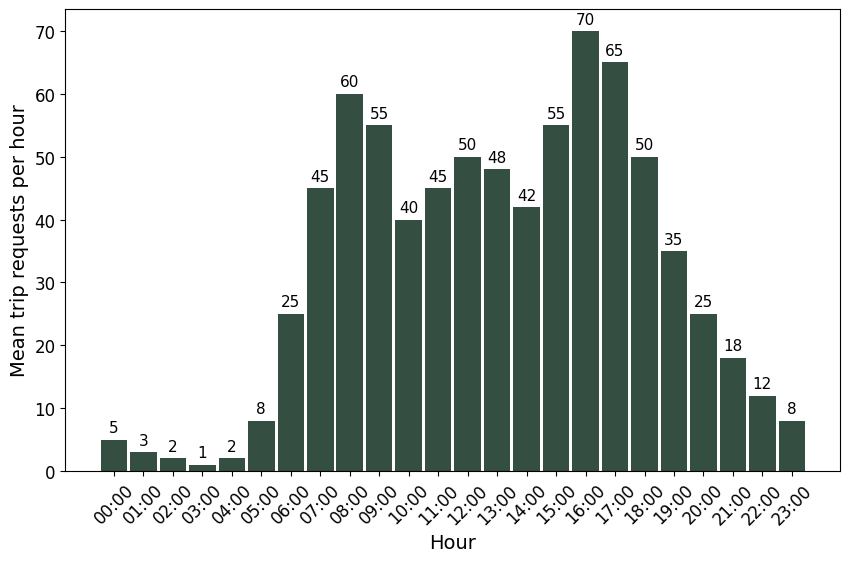

In [19]:
print("\n1. Hourly Bar Plot (Demand Example)")

hours = list(range(24))
demand = [5, 3, 2, 1, 2, 8, 25, 45, 60, 55, 40, 45, 50, 48, 42, 55, 70, 65, 50, 35, 25, 18, 12, 8]

plot_bar_hourly(
    hours=hours,
    values=demand,
    ylabel="Mean trip requests per hour",
    color=ACTIVITY_COLORS["Demand"],
    #save_as="demo_hourly_demand.svg"
)

### 6.2 Example: Timeline with Dual Axis


2. Timeline Plot with Dual Axis


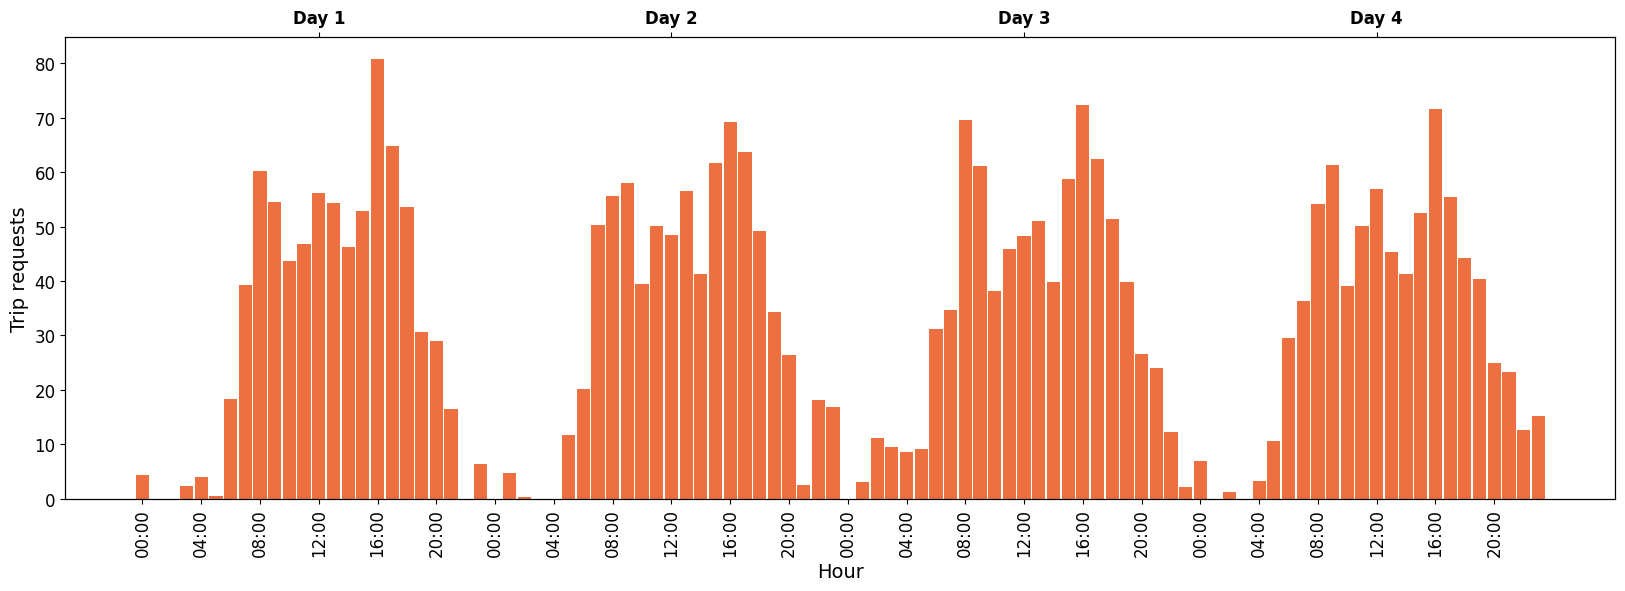

In [20]:
print("\n2. Timeline Plot with Dual Axis")

# Create 4 days of hourly data
n_hours = 4 * 24
x_timeline = np.arange(n_hours)

# Simulate daily pattern
pattern = np.array([5, 3, 2, 1, 2, 8, 25, 45, 60, 55, 40, 45, 50, 48, 42, 55, 70, 65, 50, 35, 25, 18, 12, 8])
values_timeline = np.tile(pattern, 4) + np.random.normal(0, 5, n_hours)
values_timeline = np.maximum(values_timeline, 0)  # No negative values

# Create hour labels
hour_labels_timeline = [format_hour_label(i % 24) for i in range(n_hours)]

# Day boundaries and labels
day_positions = [12, 36, 60, 84]
day_labels_list = [f"Day {i}" for i in range(1, 5)]

plot_timeline_dual_axis(
    x=x_timeline,
    values=values_timeline,
    day_labels=day_labels_list,
    day_positions=day_positions,
    hour_labels=hour_labels_timeline,
    ylabel="Trip requests",
    color=ACTIVITY_COLORS["Bike_starvations"],
    #save_as="demo_timeline.svg"
)

### 6.3 Example: Line Plot with Moving Average (Criticality)


3. Line Plot with Moving Average (Criticality)


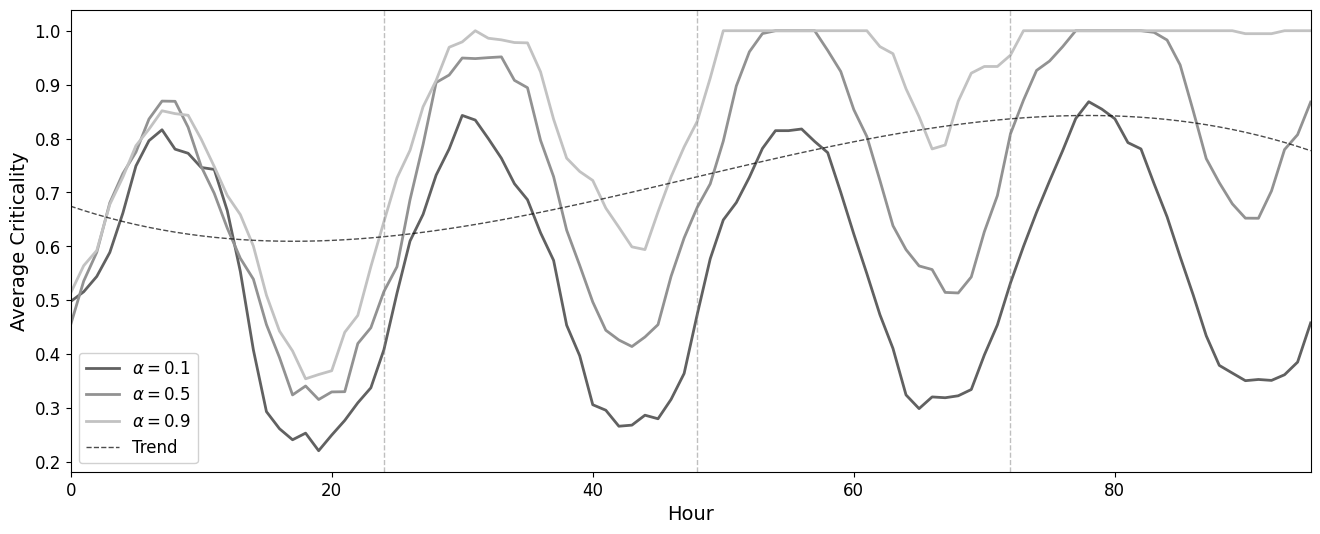

In [24]:
print("\n3. Line Plot with Moving Average (Criticality)")

# Create 3 different alpha scenarios
n_points = 96  # 4 days
x_line = np.arange(n_points)

df_list = []
labels_list = []
colors_list = []

for i, alpha in enumerate([0.1, 0.5, 0.9]):
    # Simulate criticality with trend
    base = 0.5 + 0.3 * np.sin(x_line * 2 * np.pi / 24)  # Daily cycle
    trend = alpha * x_line / n_points  # Increasing trend based on alpha
    noise = np.random.normal(0, 0.05, n_points)
    
    criticality = base + trend + noise
    criticality = np.clip(criticality, 0, 1)
    
    # Create DataFrame with moving average
    df = pd.DataFrame({'Criticality': criticality})
    df['MA'] = df['Criticality'].rolling(window=3, min_periods=1).mean()
    
    df_list.append(df)
    labels_list.append(rf"$\alpha = {alpha}$")
    colors_list.append(get_color(i, palette="grayscale"))

# Day boundaries
boundaries = [24, 48, 72]

plot_line_with_moving_average(
    df_list=df_list,
    labels=labels_list,
    colors=colors_list,
    xlabel="Hour",
    ylabel="Average Criticality",
    show_trend=True,
    trend_index=1,
    day_boundaries=boundaries,
    #save_as="demo_criticality.svg"
)

### 6.4 Example: Grouped Bar Comparison


4. Grouped Bar Comparison


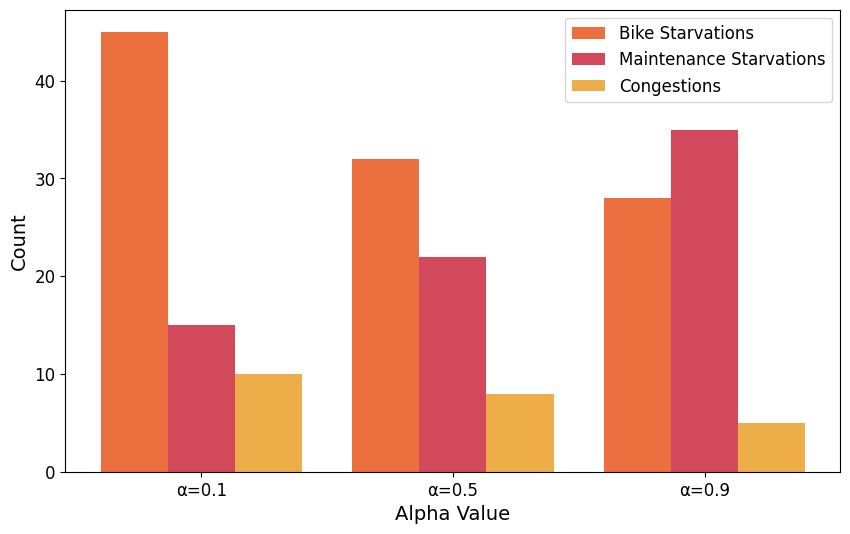

In [22]:
print("\n4. Grouped Bar Comparison")

alpha_values = ["α=0.1", "α=0.5", "α=0.9"]
metrics = {
    "Bike Starvations": [45, 32, 28],
    "Maintenance Starvations": [15, 22, 35],
    "Congestions": [10, 8, 5]
}

metric_colors = [
    ACTIVITY_COLORS["Bike_starvations"],
    ACTIVITY_COLORS["Maint_starvations"],
    ACTIVITY_COLORS["Congestions"]
]

plot_comparison_bars(
    categories=alpha_values,
    values_dict=metrics,
    xlabel="Alpha Value",
    ylabel="Count",
    colors=metric_colors,
    #save_as= "demo_comparison.svg"
)

## 7. Summary

### How to Use This Template

1. **Import or copy cells** from this notebook into your analysis notebook
2. **Call `setup_plot_style()`** at the beginning of your analysis
3. **Use the template functions** for consistent plotting:
   - `plot_bar_hourly()` - Hourly bar charts
   - `plot_timeline_dual_axis()` - Timeline with day/hour axes
   - `plot_line_with_moving_average()` - Multi-line plots with MA
   - `plot_comparison_bars()` - Grouped bar comparisons
4. **Access colors** via:
   - `ACTIVITY_COLORS` dictionary for specific activities
   - `get_color(index)` for sequential colors
   - `PRIMARY_COLORS` or `GRAYSCALE_COLORS` lists

### Available Color Palettes

- **PRIMARY_COLORS**: Main color palette (8 colors)
- **GRAYSCALE_COLORS**: Grayscale palette for criticality plots (5 colors)
- **ACTIVITY_COLORS**: Pre-defined colors for specific metrics

### Helper Functions

- `setup_plot_style()`: Configure matplotlib defaults
- `save_plot()`: Save with consistent settings
- `format_hour_label()`: Format hours as HH:00
- `process_time_data()`: Process hourly data with moving average